Due to the large size of the ResNet18 model, I have not sent this.

To run the codes in this file, you must place the resnet18-f37072fd.pth file next to the q1.ipynb file.

# سوال اول - بخش دوم

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet18
from sklearn.linear_model import Lasso

def load_image(path):
    img = Image.open(path).convert('RGB')
    return img.resize((224, 224))

def kmeans_numpy(X, n_clusters, max_iter=100, tol=1e-4):
    n = X.shape[0]
    # Randomly choose initial centroids from the data
    idx = np.random.choice(n, size=n_clusters, replace=False)
    centroids = X[idx].copy()
    labels = np.zeros(n, dtype=np.int32)
    for it in range(max_iter):
        # Assign each point to nearest centroid
        dists = np.linalg.norm(X[:, None] - centroids[None], axis=2)  # (n, k)
        new_labels = np.argmin(dists, axis=1)
        # Update centroids
        new_centroids = np.array([X[new_labels == j].mean(axis=0) 
                                  for j in range(n_clusters)])
        # If a cluster is empty, re‑initialize its centroid randomly
        for j in range(n_clusters):
            if not np.any(new_labels == j):
                new_centroids[j] = X[np.random.choice(n)]
        # Check convergence
        if np.allclose(centroids, new_centroids, atol=tol):
            labels = new_labels
            centroids = new_centroids
            break
        centroids = new_centroids
        labels = new_labels
    return centroids, labels


def kmeans_segments(image_uint8, n_segments=64, max_iter=50):
    H, W = image_uint8.shape[:2]
    xs, ys = np.meshgrid(np.arange(W), np.arange(H))
    features = np.column_stack([
        image_uint8.reshape(-1, 3).astype(float),
        ys.ravel().astype(float) * (255.0 / H) ,
        xs.ravel().astype(float) * (255.0 / W)
    ])
    centroids, labels = kmeans_numpy(features, n_segments, 
                                     max_iter=max_iter)
    return labels.reshape(H, W)

In [ ]:
MODEL_PATH = "resnet18-f37072fd.pth"    
np.random.seed(42)          
torch.manual_seed(42)      

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Load model architecture and weights
model = resnet18(weights=None)   
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("Model loaded from", MODEL_PATH)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


Using device: cpu
Model loaded from ../Model Weights/resnet18-f37072fd.pth


### زیربخش اول

In [47]:
img = load_image("cat.jpg")

normalized_img = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    out = model(normalized_img)
    prob = torch.softmax(out, dim=1)[0, 282].item()

print("Probability of belonging to the cat class:", f"{prob:.2f}")

Probability of belonging to the cat class: 0.91


### زیربخش دوم

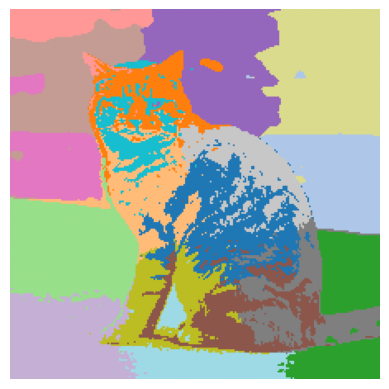

In [48]:
img_np = np.array(img)

partitions = kmeans_segments(img_np, n_segments=18)

plt.imshow(partitions, cmap='tab20')  
plt.axis('off')
plt.show()

### زیربخش سوم

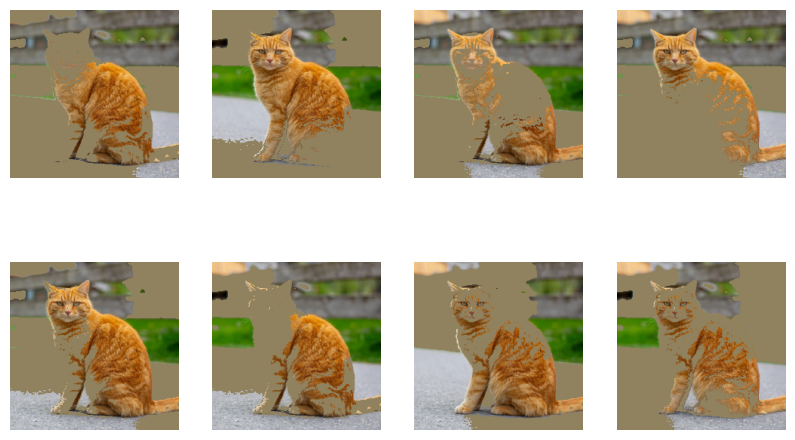

In [50]:
Z = np.random.randint(0, 2, size=(1000, 18))

mean_color = img_np.mean(axis=(0, 1))

def change_image(image, partitions, z):
    new_image = image.copy()
    for i in range(18):
        if z[i] == 0:
            new_image[partitions == i] = mean_color
    return new_image.astype(np.uint8)

changed_images = [change_image(img_np, partitions, z) for z in Z]

plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(changed_images[i])
    plt.axis("off")

plt.show()

### زیربخش چهارم

In [53]:
ones = np.ones(18)
d = 18
sigma = 0.25 * np.sqrt(d)
epsilon = 1e-8

weights = []

for z in Z:
    dist = 1 - np.dot(z, np.ones(d)) / (np.linalg.norm(z) * np.linalg.norm(np.ones(d)) + epsilon)
    w = np.exp(-(dist ** 2) / (sigma ** 2))
    weights.append(w)

weights = np.array(weights)

### زیربخش پنجم

In [54]:
probs = []

for img_arr in changed_images:
    img_pil = Image.fromarray(img_arr)
    normalized_img2 = transform(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(normalized_img2)
        prob = torch.softmax(out, dim=1)[0, 282].item()

    probs.append(prob)

probs = np.array(probs)

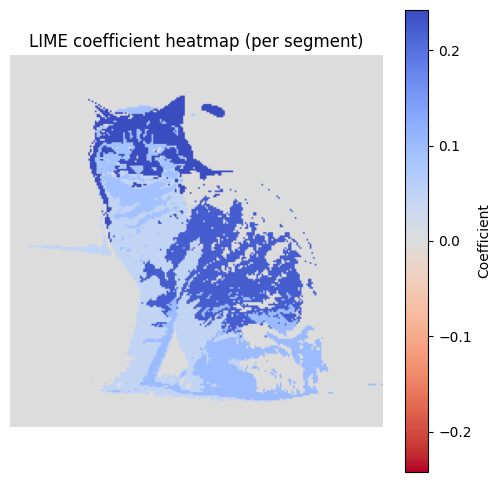

In [58]:
lasso = Lasso(alpha=0.1, fit_intercept=False)
lasso.fit(Z, probs, sample_weight=weights)

coefficients = lasso.coef_

heatmap = np.zeros(partitions.shape)

for i in range(18):
    heatmap[partitions == i] = coefficients[i]

limit = max(abs(coefficients.min()), abs(coefficients.max()))

plt.figure(figsize=(6, 6))
plt.imshow(heatmap, cmap="coolwarm_r", vmin=-limit, vmax=limit)
plt.axis("off")
plt.colorbar(label="Coefficient")
plt.title("LIME coefficient heatmap (per segment)")
plt.show()

### زیربخش ششم

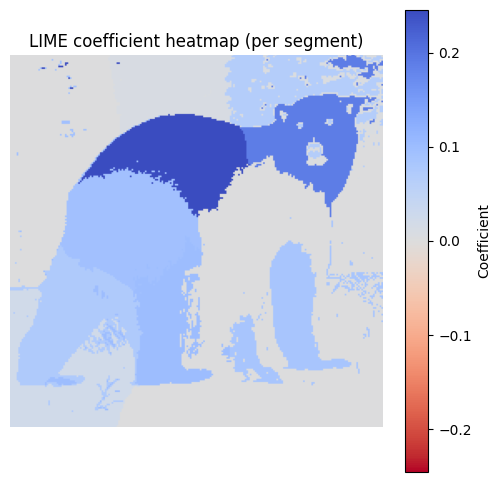

In [59]:
img2 = load_image("polarBear.png")
img_np2 = np.array(img2)

partitions2 = kmeans_segments(img_np2, n_segments=18)

Z2 = np.random.randint(0, 2, size=(1000, 18))
mean_color2 = img_np2.mean(axis=(0, 1)).astype(np.uint8)

changed_images2 = [change_image(img_np2, partitions2, z) for z in Z2]

d2 = 18
sigma2 = 0.25 * np.sqrt(d2)
epsilon2 = 1e-8

weights2 = []

for z in Z2:
    dist2 = 1 - np.dot(z, np.ones(d2)) / (np.linalg.norm(z) * np.linalg.norm(np.ones(d2)) + epsilon2)
    w2 = np.exp(-(dist2 ** 2) / (sigma2 ** 2))
    weights2.append(w2)

weights2 = np.array(weights2)

probs2 = []

for img_arr2 in changed_images2:
    img_pil2 = Image.fromarray(img_arr2)
    x2 = transform(img_pil2).unsqueeze(0).to(device)

    with torch.no_grad():
        out2 = model(x2)
        prob2 = torch.softmax(out2, dim=1)[0, 296].item()

    probs2.append(prob2)

probs2 = np.array(probs2)

lasso2 = Lasso(alpha=0.1, fit_intercept=False)
lasso2.fit(Z2, probs2, sample_weight=weights2)

coefficients2 = lasso2.coef_

heatmap2 = np.zeros(partitions2.shape)

for i in range(18):
    heatmap2[partitions2 == i] = coefficients2[i]

limit2 = max(abs(coefficients2.min()), abs(coefficients2.max()))

plt.figure(figsize=(6, 6))
plt.imshow(heatmap2, cmap="coolwarm_r", vmin=-limit2, vmax=limit2)
plt.axis("off")
plt.colorbar(label="Coefficient")
plt.title("LIME coefficient heatmap (per segment)")
plt.show()